# Esperimenti HERMES Quantum Simulator - Topologia Lineare
Questo notebook permette di automatizzare i test sperimentali modificando i parametri delle topologie ed estraendo i risultati per la visualizzazione.

In [ ]:
import json
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil

# Spostiamoci nella root del progetto per usare i percorsi corretti
if os.getcwd().endswith('notebooks'):
    os.chdir('../../')
print(f"Directory di lavoro attuale: {os.getcwd()}")

# Creiamo la cartella dedicata per i plot
os.makedirs(os.path.join('results', 'plots'), exist_ok=True)

In [ ]:
def run_experiment(topology_file, config_updates, simulation_script, default_csv, custom_csv_name):
    """
    Modifica temporaneamente il JSON della topologia, lancia la simulazione 
    e salva i risultati in un CSV con nome dedicato.
    """
    # 1. Backup file originale
    backup_file = topology_file + '.bak'
    if not os.path.exists(backup_file):
        shutil.copy(topology_file, backup_file)

    # 2. Carica e applica le modifiche
    with open(backup_file, 'r') as f:
        data = json.load(f)
    
    if 'parameters' in data:
        for key, val in config_updates.items():
            data['parameters'][key] = val
            
    # 3. Sovrascrivi temporaneamente per l'esecuzione
    with open(topology_file, 'w') as f:
        json.dump(data, f, indent=2)
        
    print(f"Esecuzione {simulation_script} con parametri: {config_updates}...")
    subprocess.run(["python", simulation_script], check=True, stdout=subprocess.DEVNULL)
    
    # Ripristina originale
    shutil.copy(backup_file, topology_file)
    
    # 4. Copia il CSV generato in uno con nome dedicato
    if os.path.exists(default_csv):
        shutil.copy(default_csv, custom_csv_name)
    else:
        print(f"ATTENZIONE: File {default_csv} non trovato dopo la simulazione.")
        
    df = pd.read_csv(custom_csv_name)
    return df

## 1. Test: Variazione Attenuazione (Fiber Attenuation)
Aspettativa: All'aumentare dell'attenuazione, i fotoni andranno persi. L'SKR scenderà notevolmente. Il QBER salirà gradualmente.

In [ ]:
attenuations = [0.1, 0.2, 0.3]
results_att = {}

for att in attenuations:
    custom_csv = f'results/linear_att_{att}.csv'
    df = run_experiment(
        topology_file='config/linear_topology.json',
        config_updates={'fiber_attenuation_db_per_km': att},
        simulation_script='sim_linear.py',
        default_csv='results/linear_metrics.csv',
        custom_csv_name=custom_csv
    )
    results_att[att] = df

print("Simulazioni completate!")

Plot salvato in: results/plots/exp1_attenuation.png


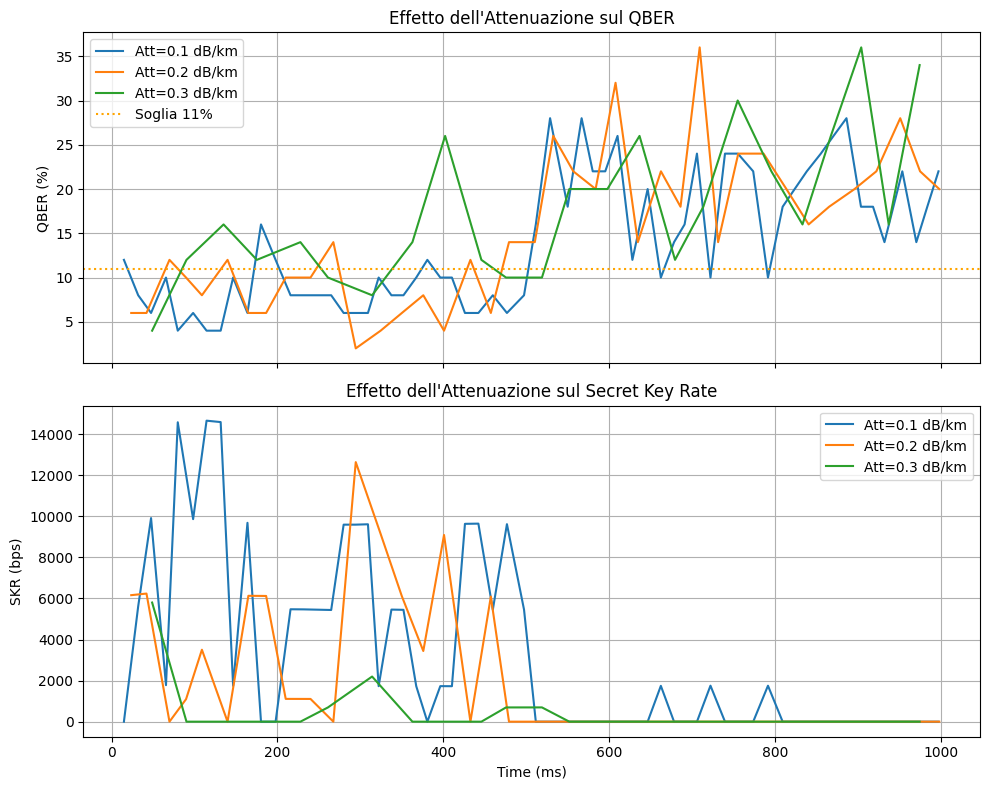

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for att, df in results_att.items():
    time_ms = df['time_stamp'] / 1e6
    ax1.plot(time_ms, df['qber']*100, label=f"Att={att} dB/km")
    ax2.plot(time_ms, df['skr_bps'], label=f"Att={att} dB/km")

ax1.set_ylabel("QBER (%)")
ax1.set_title("Effetto dell'Attenuazione sul QBER")
ax1.axhline(y=11, color='orange', linestyle=':', label="Soglia 11%")
ax1.legend()
ax1.grid(True)

ax2.set_ylabel("SKR (bps)")
ax2.set_xlabel("Time (ms)")
ax2.set_title("Effetto dell'Attenuazione sul Secret Key Rate")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plot_path_1 = os.path.join('results', 'plots', 'exp1_attenuation.png')
plt.savefig(plot_path_1, dpi=300)
print(f'Plot salvato in: {plot_path_1}')
plt.show()

## 2. Test: Decoerenza delle Memorie Quantistiche (T1)
Aspettativa: Abbassando T1, gli stati quantistici memorizzati perdono fedeltà più in fretta. Il QBER schizza oltre la soglia, azzerando l'SKR.

In [ ]:
t1_values = [1e9, 1e8, 1e7] # da 1 secondo a 10ms
results_t1 = {}

for t1 in t1_values:
    custom_csv = f'results/linear_t1_{int(t1)}.csv'
    df = run_experiment(
        topology_file='config/linear_topology.json',
        config_updates={'memory_T1': t1},
        simulation_script='sim_linear.py',
        default_csv='results/linear_metrics.csv',
        custom_csv_name=custom_csv
    )
    results_t1[t1] = df

print("Simulazioni completate!")

Plot salvato in: results/plots/exp2_t1_decoherence.png


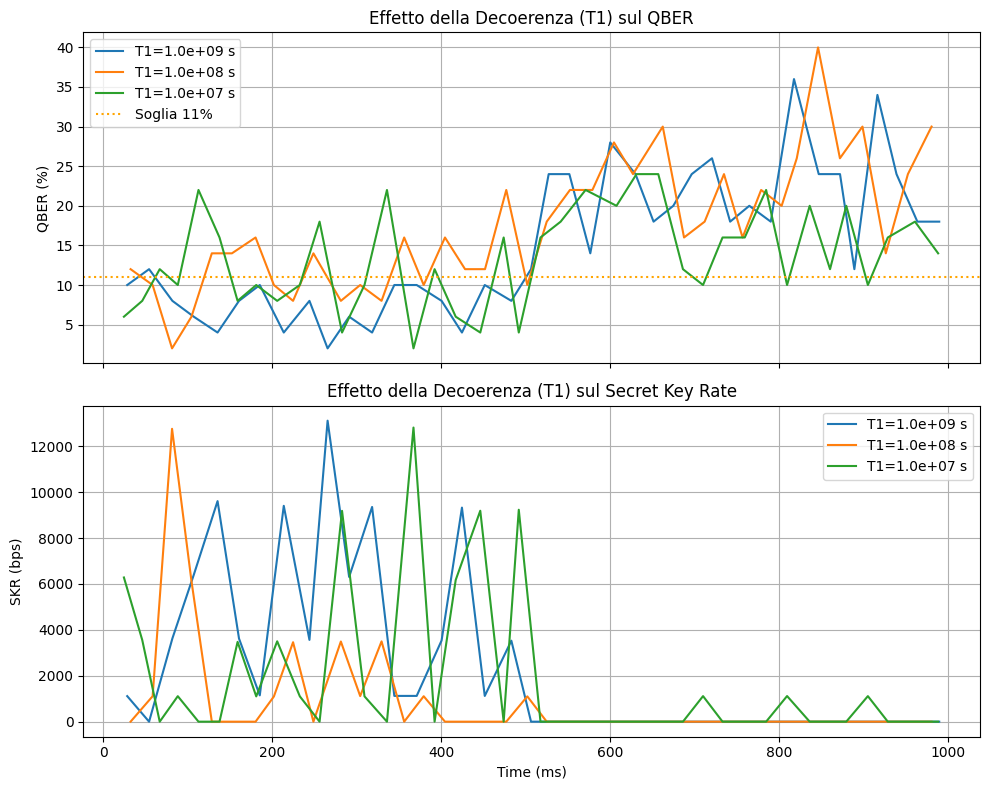

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for t1, df in results_t1.items():
    time_ms = df['time_stamp'] / 1e6
    ax1.plot(time_ms, df['qber']*100, label=f'T1={t1:.1e} s')
    ax2.plot(time_ms, df['skr_bps'], label=f'T1={t1:.1e} s')

ax1.set_ylabel('QBER (%)')
ax1.set_title('Effetto della Decoerenza (T1) sul QBER')
ax1.axhline(y=11, color='orange', linestyle=':', label='Soglia 11%')
ax1.legend()
ax1.grid(True)

ax2.set_ylabel('SKR (bps)')
ax2.set_xlabel('Time (ms)')
ax2.set_title('Effetto della Decoerenza (T1) sul Secret Key Rate')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plot_path_2 = os.path.join('results', 'plots', 'exp2_t1_decoherence.png')
plt.savefig(plot_path_2, dpi=300)
print(f'Plot salvato in: {plot_path_2}')
plt.show()